# **Project Name**    - Predictive Maintainance and Machine Failure Prediction System



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual


# **Project Summary -**

This project analyzes machine failure prediction using exploratory data analysis, feature engineering, visualization, hypothesis testing, and machine learning. The workflow includes data cleaning, understanding variable distributions, identifying relationships between operating parameters and machine failures, handling categorical variables, model training, evaluation, and interpretation. The objective is to identify factors contributing to machine failure and build a predictive model that can support proactive maintenance decisions.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Predict machine failures using operational sensor data and identify the key factors influencing failure occurrence to support predictive maintenance.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required. 
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits. 
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule. 

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df_train=pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

### Dataset First View

In [3]:
# Dataset First Look
df_train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [4]:
print(df_test.shape)
df_test.head()

(90954, 13)


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(df_train.shape)
print("rows:",df_train.shape[0])
print("columns:",df_train.shape[1])

(136429, 14)
rows: 136429
columns: 14


### Dataset Information

In [6]:
# Dataset Info
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df_train.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df_train.isnull().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [9]:
# Visualizing the missing values

#NO MISSING VALUES

### What did you know about your dataset?

The dataset consists of operational parameters collected from industrial machines and is intended for predictive maintenance and machine failure prediction. It contains 14 features and about 1,35,000 rows

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print(df_train.columns)
print(df_train.select_dtypes(include="number").columns)
print(df_train.select_dtypes(include="object").columns)

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
Index(['id', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')
Index(['Product ID', 'Type'], dtype='object')


In [11]:
# Dataset Describe
df_train.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variables Description 

Machine failure is the target variable which is either 1 or 0. and among other features 2 are categorical varibles ,6 are binary and 5 are numeric variables

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
df_train.nunique()

id                         136429
Product ID                   9976
Type                            3
Air temperature [K]            95
Process temperature [K]        81
Rotational speed [rpm]        952
Torque [Nm]                   611
Tool wear [min]               246
Machine failure                 2
TWF                             2
HDF                             2
PWF                             2
OSF                             2
RNF                             2
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.
#As there is no duplicate or null value so we already have clean data if we had then df.drop_duplicates(inplace=True) and df.fill_na(df.mean(numeric_onlu=True),inplace=True)
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_train["Type"]=le.fit_transform(df_train["Type"])


### What all manipulations have you done and insights you found?

1.Checked the dataset for missing values and found that there were no null values, so no imputation was required.

2.Verified the dataset for duplicate records and observed that the data was already clean, eliminating the need for duplicate removal.

3.Examined the unique values of each variable to understand the nature and categories of the features.

4.Converted the categorical variable Type into numerical format using Label Encoding, making it suitable for machine learning algorithms.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

<Axes: xlabel='Machine failure', ylabel='count'>

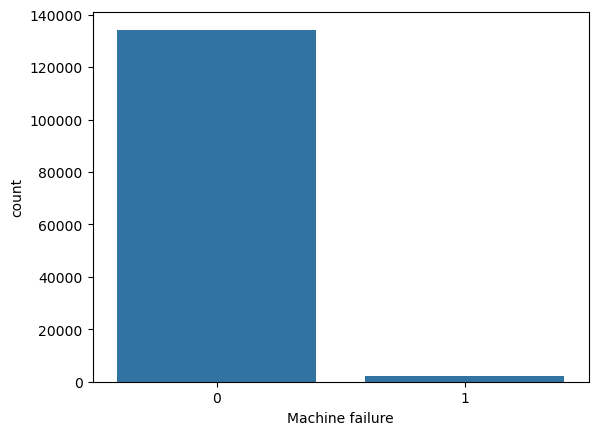

In [14]:
# Chart - 1 visualization code
sns.countplot(x=df_train["Machine failure"])

##### 1. Why did you pick the specific chart?

A count plot was chosen because the target variable Machine failure is categorical (0 = No Failure, 1 = Failure). It effectively shows the frequency of each class and helps identify the distribution and any class imbalance in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The number of non-failure cases (0) is significantly higher than the failure cases (1).

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

The low frequency of failures suggests that implementing a predictive maintenance system can help detect failures early, reducing unexpected downtime and maintenance costs.

#### Chart - 2

<Axes: xlabel='Type', ylabel='count'>

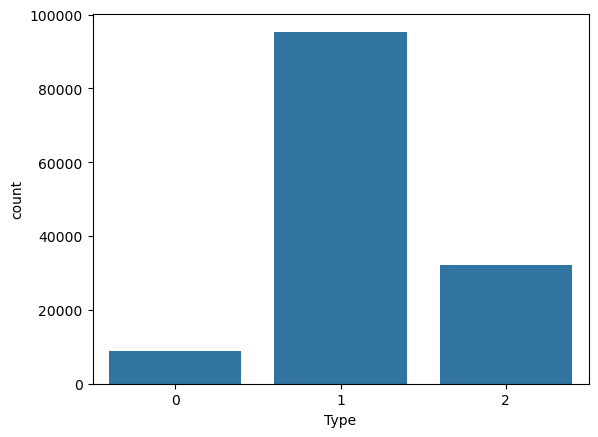

In [15]:
# Chart - 2 visualization code
sns.countplot(x=df_train["Type"])

##### 1. Why did you pick the specific chart?

A count plot was chosen because Type is a categorical variable (L, M, H). It clearly shows the number of machines belonging to each type

##### 2. What is/are the insight(s) found from the chart?

The dataset contains three machine types: Low (L), Medium (M), and High (H).

The Low (L) type machines are the most frequent, followed by Medium (M), while High (H) machines are the least common.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can have a positive business impact.

Understanding the distribution of machine types helps organizations allocate maintenance resources more effectively.

#### Chart - 3

<Axes: xlabel='Machine failure', ylabel='Torque [Nm]'>

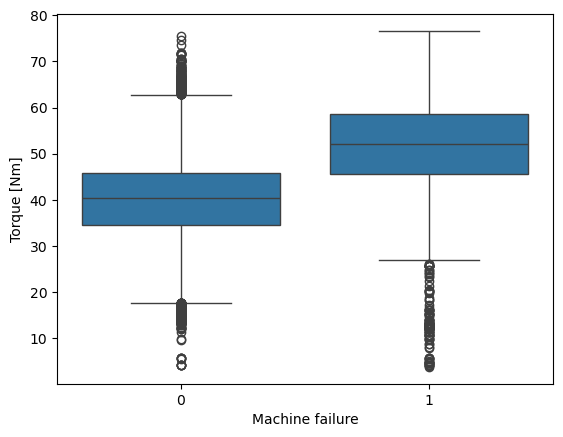

In [16]:
# Chart - 3 visualization code
sns.boxplot(y=df_train["Torque [Nm]"],x=df_train["Machine failure"]) #To see if Torque is affected by type of machine

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of Torque [Nm] for machines with and without failure. It helps visualize the median, spread, and potential outliers, making it useful for understanding whether torque is associated with machine failure.

##### 2. What is/are the insight(s) found from the chart?

The torque values differ between failed and non-failed machines.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can create a positive business impact.

Monitoring torque levels can help identify abnormal machine conditions and enable preventive maintenance, reducing unexpected breakdowns and downtime.

#### Chart - 4

<Axes: xlabel='Type', ylabel='count'>

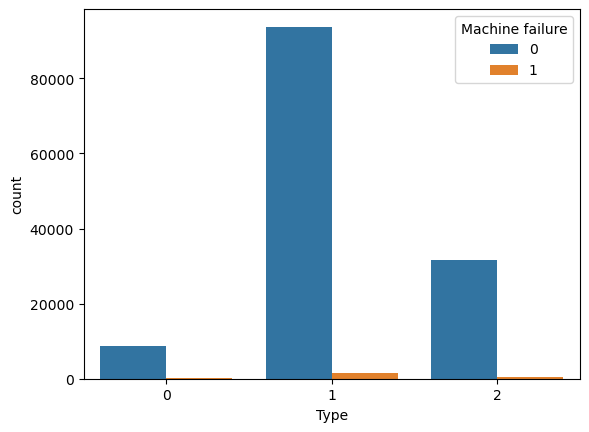

In [17]:
# Chart - 4 visualization code
sns.countplot(x="Type", hue="Machine failure", data=df_train)

##### 1. Why did you pick the specific chart?

A count plot was chosen to compare the distribution of machine failures across different machine types (L, M, H). It helps identify whether a particular machine type is more prone to failure.

##### 2. What is/are the insight(s) found from the chart?

The number of failures varies across machine types.
Low (L) type machines are more common in the dataset.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Helps prioritize maintenance strategies for machine types with higher failure occurrences.

#### Chart - 5

<Axes: xlabel='Torque [Nm]', ylabel='Rotational speed [rpm]'>

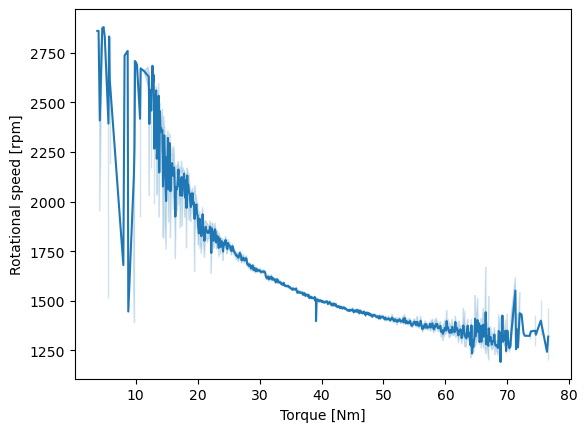

In [18]:
# Chart - 5 visualization code
sns.lineplot(data=df_train,x=df_train["Torque [Nm]"],y=df_train["Rotational speed [rpm]"]) #To see if there is any relation between the two

##### 1. Why did you pick the specific chart?

line plot was chosen to visualize the relationship between Torque and Rotational Speed. It helps observe how rotational speed changes with varying torque values and identify overall trends

##### 2. What is/are the insight(s) found from the chart?

Generally, higher torque is associated with lower rotational speed, indicating an inverse relationship between the two variables.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Monitoring the relationship between torque and rotational speed helps detect abnormal operating conditions.

#### Chart - 6

<Axes: xlabel='Torque [Nm]', ylabel='Count'>

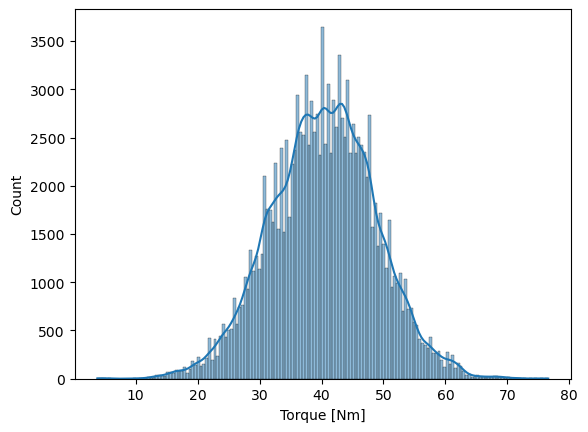

In [19]:
# Chart - 6 visualization code
sns.histplot(x=df_train["Torque [Nm]"],kde=True)

##### 1. Why did you pick the specific chart?

A histogram with KDE (Kernel Density Estimation) was chosen to visualize the distribution of the Torque [Nm] feature. It helps understand how torque values are spread, their frequency, and whether the data follows a normal or skewed distribution.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of torque values across all machines.

Most observations are concentrated within a specific torque range, while very high or very low torque values occur less frequently.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the normal operating range of torque helps define thresholds for anomaly detection.

#### Chart - 7

<Axes: xlabel='Air temperature [K]', ylabel='Count'>

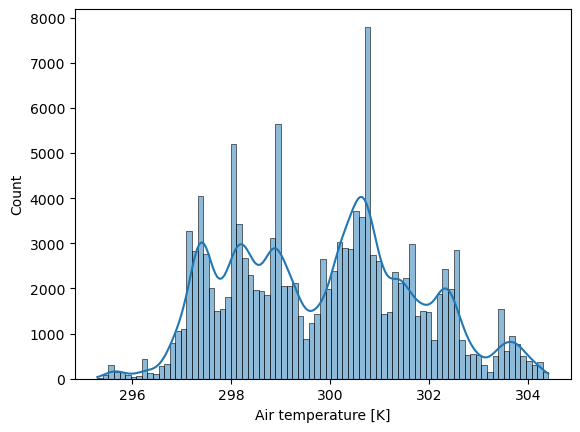

In [20]:
# Chart - 7 visualization code
sns.histplot(x=df_train["Air temperature [K]"],kde=True)

##### 1. Why did you pick the specific chart?

A histogram with KDE was chosen to visualize the distribution of Air Temperature [K]. It helps understand the frequency of different temperature values, identify the data distribution, and detect any skewness or unusual patterns.

##### 2. What is/are the insight(s) found from the chart?

There are very few extreme temperature values, suggesting that most machines operate under stable ambient conditions.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Monitoring air temperature helps detect abnormal environmental conditions that may affect machine performance.

#### Chart - 8

<Axes: xlabel='Process temperature [K]', ylabel='Count'>

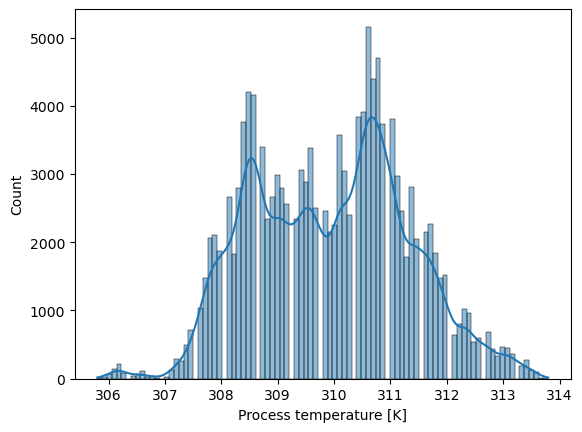

In [21]:
# Chart - 8 visualization code
sns.histplot(x=df_train["Process temperature [K]"],kde=True)

##### 1. Why did you pick the specific chart?

A histogram with KDE was chosen to visualize the distribution of Process Temperature [K]. It helps understand how process temperature values are distributed, identify the most common operating range, and detect any skewness or unusual values.

##### 2. What is/are the insight(s) found from the chart?

Most process temperature values are concentrated within a specific range, indicating stable machine operating conditions.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Monitoring process temperature enables early detection of abnormal machine behavior.

#### Chart - 9

<Axes: xlabel='PWF', ylabel='count'>

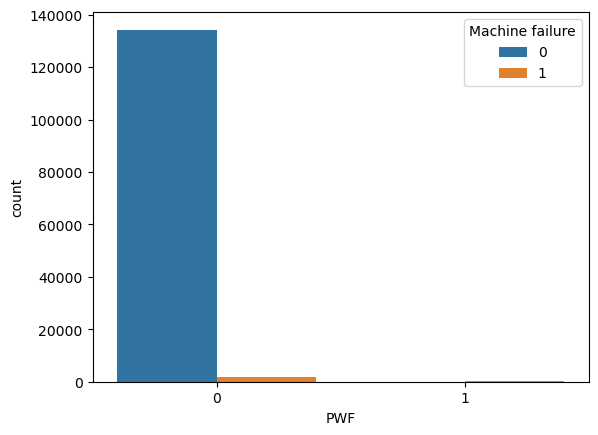

In [22]:
# Chart - 9 visualization code
sns.countplot(x="PWF", hue="Machine failure", data=df_train)

##### 1. Why did you pick the specific chart?

A count plot was chosen to examine the relationship between Machine Failure and Power Failure (PWF). It helps identify whether machine failures are associated with power failure events.

##### 2. What is/are the insight(s) found from the chart?

Most observations have PWF = 0, indicating that power failures are relatively uncommon.
When PWF = 1, machine failures are more likely to occur.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Monitoring power-related issues can help identify potential machine failures before they occur.

#### Chart - 10

<Axes: xlabel='PWF', ylabel='Process temperature [K]'>

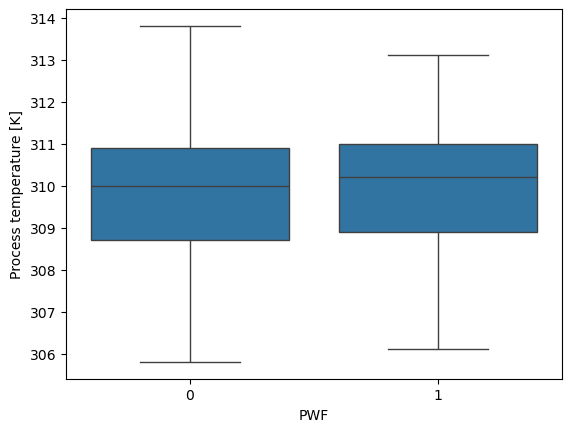

In [23]:
# Chart - 10 visualization code
# Chart - 9 visualization code
sns.boxplot(y=df_train["Process temperature [K]"],x=df_train["PWF"])

##### 1. Why did you pick the specific chart?

Boxplot was chosen to examine the relationship between Power Failure (PWF) and Process Temperature [K].

##### 2. What is/are the insight(s) found from the chart?

The process temperature values can be compared between machines with and without power failures.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Monitoring process temperature can help identify conditions that may lead to power failures.

#### Chart - 11

<Axes: xlabel='Type', ylabel='Tool wear [min]'>

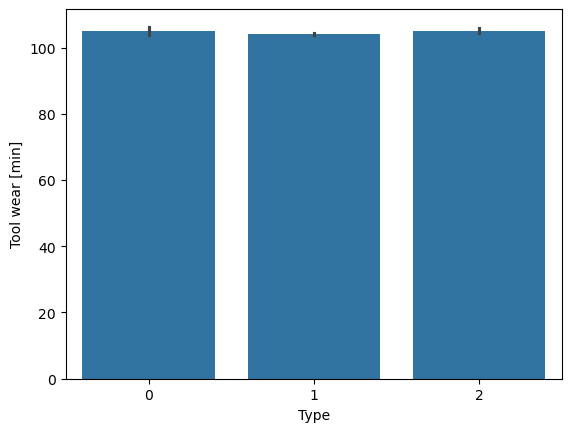

In [24]:
# Chart - 11 visualization code
sns.barplot(x=df_train["Type"],y=df_train["Tool wear [min]"])

##### 1. Why did you pick the specific chart?

bar plot was chosen to compare the average Tool Wear (in minutes) across different machine Types (L, M, H). It provides a clear comparison of tool wear among the machine categories.

##### 2. What is/are the insight(s) found from the chart?

Tt helps identify which machine type experiences higher tool wear and may require more frequent maintenance.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying machine types with higher average tool wear helps schedule preventive maintenance and timely tool replacement.

#### Chart - 12

<Axes: xlabel='Rotational speed [rpm]'>

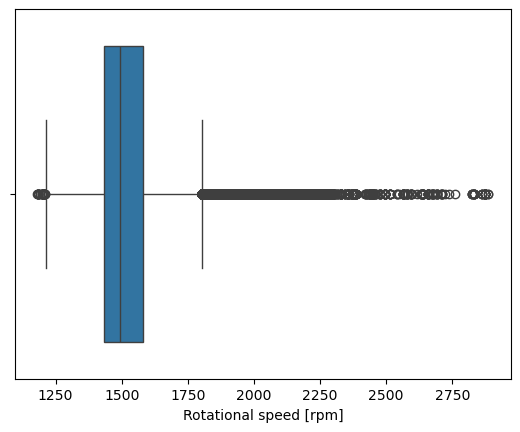

In [25]:
# Chart - 12 visualization code
sns.boxplot(x=df_train["Rotational speed [rpm]"])

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the distribution of Rotational Speed (RPM). It helps identify the median, spread, quartiles, and potential outliers, making it useful for detecting unusual operating conditions.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the central tendency and variability of rotational speed.

It helps identify outliers, which may represent machines operating at abnormally high or low speeds.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Detecting abnormal rotational speeds enables early maintenance planning, reducing the risk of machine failure and minimizing downtime.

#### Chart - 13

<Axes: xlabel='Type', ylabel='Machine failure'>

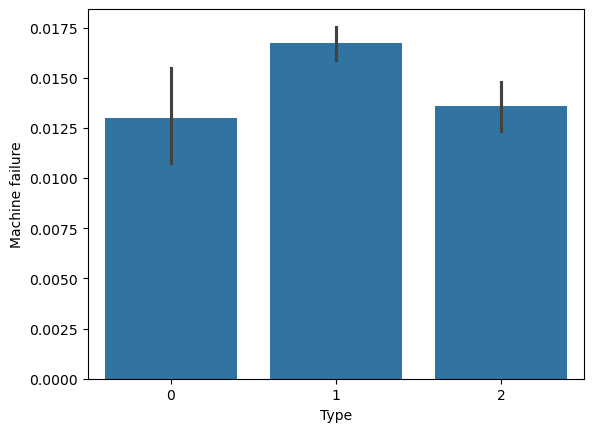

In [26]:
# Chart - 13 visualization code
sns.barplot(x=df_train["Type"],y=df_train["Machine failure"])

##### 1. Why did you pick the specific chart?

A bar plot was chosen to compare the average machine failure rate across different machine types (L, M, H). It helps determine whether a particular machine type is more prone to failures.

##### 2. What is/are the insight(s) found from the chart?

It helps identify which machine type has a higher probability of failure.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying machine types with higher failure rates allows companies to prioritize maintenance, inspections, and resource allocation

#### Chart - 14 - Correlation Heatmap

<Axes: >

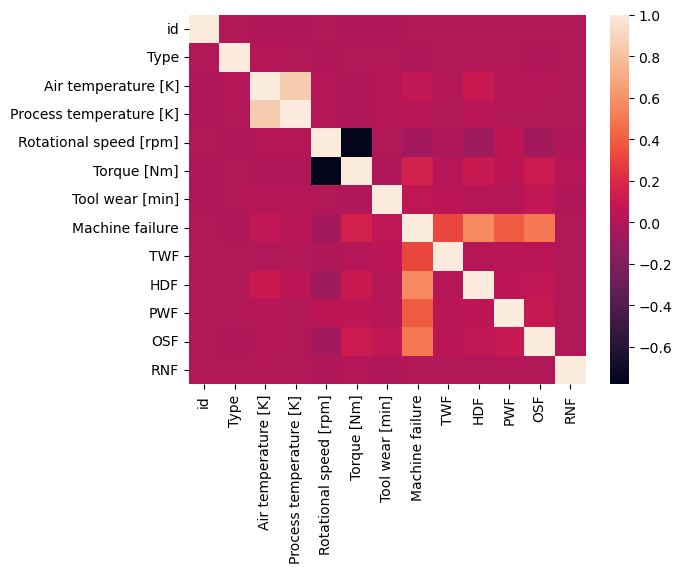

In [27]:
# Correlation Heatmap visualization code
sns.heatmap(df_train.corr(numeric_only=True))

In [28]:
corr=df_train.corr(numeric_only=True)
corr["Machine failure"].abs().sort_values(ascending=False).drop("Machine failure")

HDF                        0.564507
OSF                        0.494668
PWF                        0.383941
TWF                        0.311919
Torque [Nm]                0.145793
Air temperature [K]        0.067744
Rotational speed [rpm]     0.060868
Tool wear [min]            0.056448
Process temperature [K]    0.030966
Type                       0.005049
id                         0.001500
RNF                        0.001428
Name: Machine failure, dtype: float64

##### 1. Why did you pick the specific chart?

A heatmap was chosen to visualize the correlation between numerical variables in the dataset. It helps identify strong positive or negative relationships between features and highlights which variables are most associated with machine failure.

##### 2. What is/are the insight(s) found from the chart?

The heatmap reveals the strength and direction of correlations among numerical features.

#### Chart - 15 - Pair Plot 

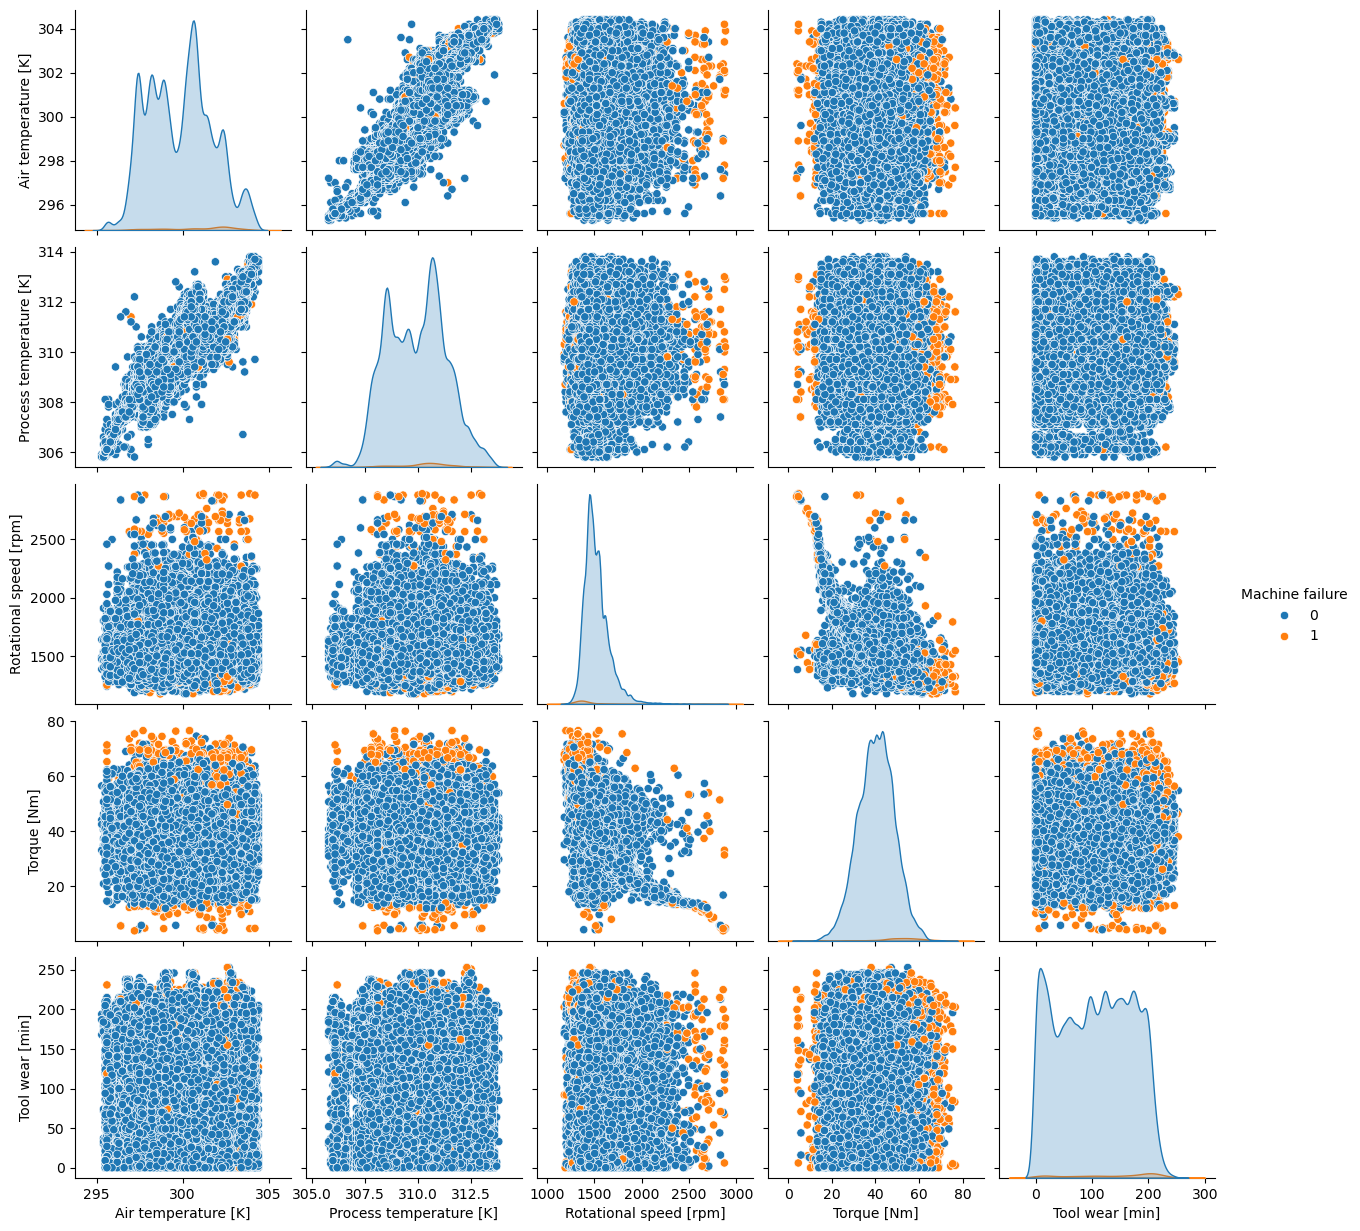

In [29]:
# Pair Plot visualization code(PAIR PLOT visulaize the relation b/w numerical columns)
cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]# choose features which are important means highly correlated
#not included Because these are failure-type indicator columns (Heat Dissipation Failure, Overstrain Failure, etc.). If your target is Machine failure, these columns are almost directly related to the target and can cause data leakage
sns.pairplot(df_train[cols],hue="Machine failure")

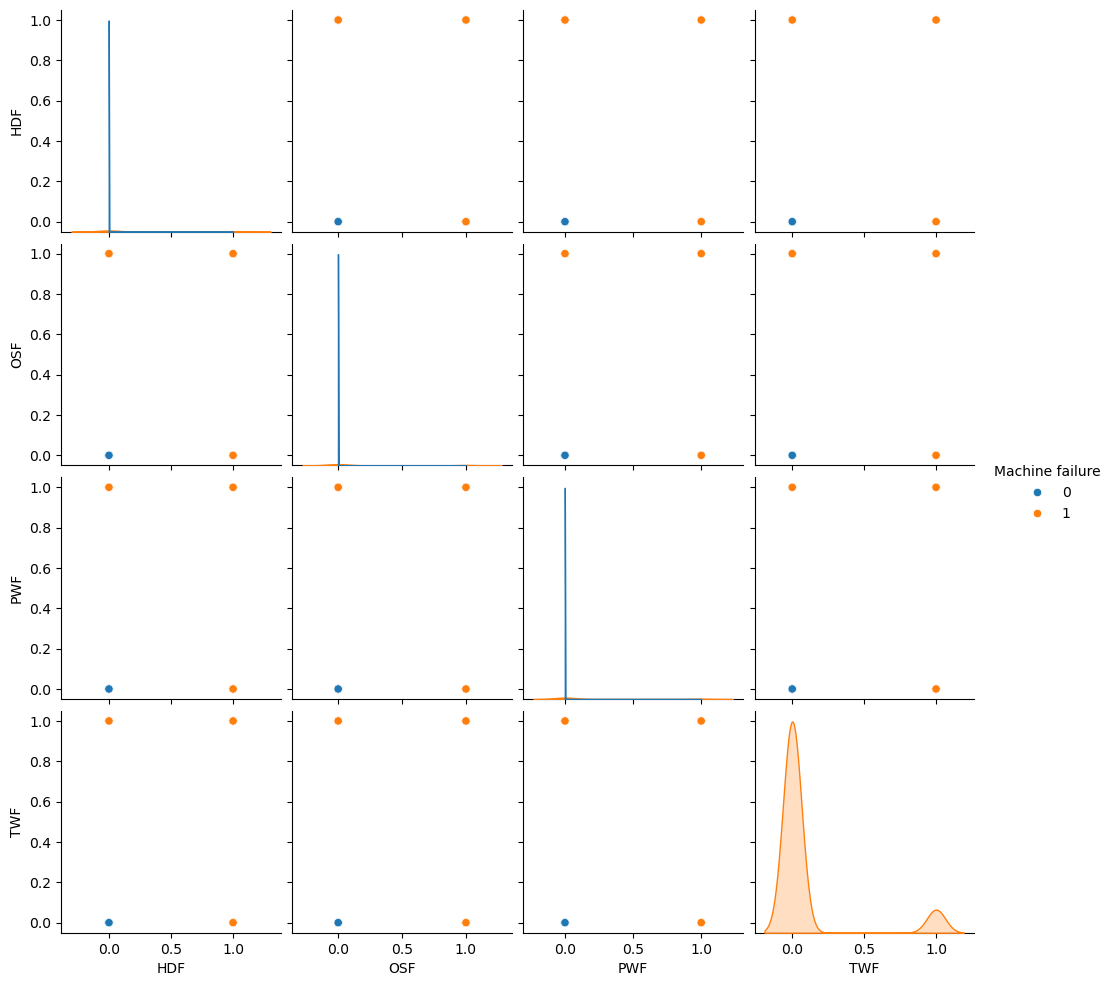

In [30]:
sns.pairplot(
    df_train[['HDF','OSF','PWF','TWF','Machine failure']],
    hue='Machine failure'
    
) # When goal is purely EDA and not modeling

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the pairwise relationships among important numerical features such as Air Temperature, Process Temperature, Rotational Speed, Torque, and Tool Wear, with respect to the Machine Failure target variable.

##### 2. What is/are the insight(s) found from the chart?

The pair plot reveals the relationships between multiple numerical features simultaneously.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀ (Null Hypothesis):
There is no significant difference in tool wear between failed and non-failed machines.

H₁ (Alternative Hypothesis):
There is a significant difference in tool wear between failed and non-failed machines.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

failure = df_train[df_train['Machine failure']==1]['Tool wear [min]']
non_failure = df_train[df_train['Machine failure']==0]['Tool wear [min]']

t_stat, p_value = ttest_ind(failure, non_failure)

print("T-statistic:", t_stat.round(10))
print("P-value:", p_value.round(10))
 

T-statistic: 20.882943834
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

An Independent Two-Sample t-test (ttest_ind) was performed to obtain the p-value and compare the mean values of a numerical feature between the Machine Failure and No Machine Failure groups.

##### Why did you choose the specific statistical test?

The Independent t-test (ttest_ind) was chosen because it is used to compare the means of a continuous variable between two independent groups

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀:
Mean process temperature is the same for failed and non-failed machines.

H₁:
Mean process temperature differs between failed and non-failed machines.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

failure_temp = df_train[df_train['Machine failure']==1]['Process temperature [K]']
non_failure_temp = df_train[df_train['Machine failure']==0]['Process temperature [K]']

t_stat1, p_value1 = ttest_ind(failure_temp, non_failure_temp)

print("T-statistic:", t_stat1.round(10))
print("P-value:", p_value1.round(10))
 

T-statistic: 11.443257093
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

An Independent Two-Sample t-test (ttest_ind) was performed to obtain the p-value and compare the mean values of a numerical feature between the Machine Failure and No Machine Failure groups.

##### Why did you choose the specific statistical test?

The Independent t-test (ttest_ind) was chosen because it is used to compare the means of a continuous variable between two independent groups

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀:
Product type and machine failure are independent.

H₁:
Product type and machine failure are associated.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

failure1 = df_train[df_train['Machine failure']==1]['Type']
non_failure1 = df_train[df_train['Machine failure']==0]['Type']

t_stat2, p_value2 = ttest_ind(failure1, non_failure1)

print("T-statistic:", t_stat2.round(10))
print("P-value:", p_value2.round(10))


T-statistic: -1.8649173621
P-value: 0.0621951337


##### Which statistical test have you done to obtain P-Value?

An Independent Two-Sample t-test (ttest_ind) was performed to obtain the p-value and compare the mean values of a numerical feature between the Machine Failure and No Machine Failure groups.

##### Why did you choose the specific statistical test?

The Independent t-test (ttest_ind) was chosen because it is used to compare the means of a continuous variable between two independent groups.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputations
#NO MISSING VALUES

#### What all missing value imputation techniques have you used and why did you use those techniques?

not required

### 2. Handling Outliers

<Axes: xlabel='Torque [Nm]'>

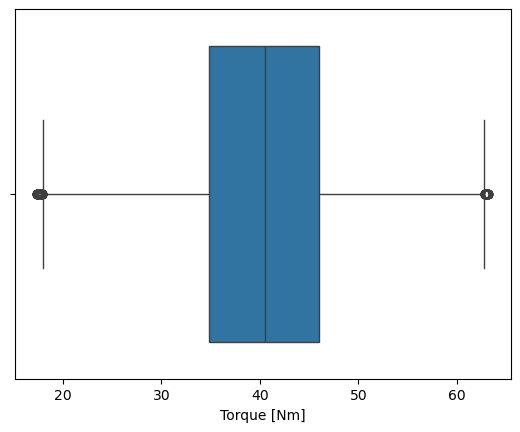

In [35]:
# Handling Outliers & Outlier treatments
q1=df_train["Torque [Nm]"].quantile(0.25)
q3=df_train["Torque [Nm]"].quantile(0.75)
iqr=q3-q1
lower=q1-iqr*1.5
higher=q3+1.5*iqr
df_clean=df_train[(df_train["Torque [Nm]"]>=lower) & (df_train["Torque [Nm]"]<=higher)]
sns.boxplot(x=df_clean["Torque [Nm]"])

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using box plots during exploratory data analysis. The Torque [Nm] feature contained significant outliers that could negatively affect model performance and analysis.

Therefore, the outliers in the Torque feature were removed to reduce the influence of extreme values and improve the quality of the dataset.

### 3. Categorical Encoding

In [36]:
# Encode your categorical columns
df_train["Type"]=le.fit_transform(df_train["Type"])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert the categorical variable Type (L, M, H) into numerical values. This transformation was necessary because machine learning algorithms cannot process categorical data directly.

### 4. Textual Data Preprocessing 
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

###  NOT NEEDED HERE BECAUSE NO FEATURE IS TEXTUAL IN THIS DATA

#### 1. Expand Contraction

In [37]:
# Expand Contraction

#### 2. Lower Casing

In [38]:
# Lower Casing

#### 3. Removing Punctuations

In [39]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [40]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [41]:
# Remove Stopwords

In [42]:
# Remove White spaces

#### 6. Rephrase Text

In [43]:
# Rephrase Text

#### 7. Tokenization

In [44]:
# Tokenization

#### 8. Text Normalization

In [45]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [46]:
# POS Taging

#### 10. Text Vectorization

In [47]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [48]:
# Manipulate Features to minimize feature correlation and create new features
df_train["temp_diff"]=(df_train["Process temperature [K]"])-(df_train["Air temperature [K]"])
df_train["temp_diff"].sort_values(ascending=False)

80822     15.0
25204     15.0
71282     14.9
42916     14.4
76844     14.2
          ... 
9878       6.5
42718      6.1
9929       5.6
12189      5.5
118267     3.2
Name: temp_diff, Length: 136429, dtype: float64

In [49]:
df_train[["temp_diff","Machine failure"]].groupby("Machine failure").mean()

,temp_diff
Machine failure,
0,10.088825
1,9.419972


In [50]:
df_train["temp_diff"].corr(df_train["Machine failure"])

np.float64(-0.08453627820433154)

#### 2. Feature Selection

In [51]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Correlation Analysis

Statistical Tests (for categorical vs target)

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

### 6. Data Splitting

In [52]:
# Scaling your data
from sklearn.model_selection import train_test_split
X=df_train.drop(columns=["Machine failure","Type","Product ID","temp_diff"]) #remove non-numeric col and target col
y=df_train["Machine failure"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Scaling


In [53]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
X_train=st.fit_transform(X_train)
X_test=st.fit_transform(X_test)

##### What data splitting ratio have you used and why? 

I have used 80:20 ratio because the model needs sufficient data to learn patterns properly.
With 80% training data, the model can capture:
relationships between features (temperature, torque, rpm, etc.)
failure patterns effectively

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Handling the imbalance dataset  is needed when dataset is highly unbalance like in this case 

In [54]:
# Handling Imbalanced Dataset (If needed)
df_train["Machine failure"].value_counts(normalize=True)*100 ##for percentage count

Machine failure
0    98.425555
1     1.574445
Name: proportion, dtype: float64

In [55]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

In [56]:
y_train_sm.value_counts()

Machine failure
0    93996
1    93996
Name: count, dtype: int64

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

I used SMOTE to balance the dataset.

SMOTE generates synthetic samples for the minority class instead of duplicating existing ones

It creates new synthetic minority samples
Instead of copying data, it generates new points using feature space interpolation

## ***7. ML Model Implementation***

### ML Model - 1

In [57]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

# Fit the Algorithm
lr.fit(X_train_sm,y_train_sm)

# Predict on the model
y_lr=lr.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [58]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import accuracy_score,classification_report
acc_lr=accuracy_score(y_test,y_lr)
class_lr=classification_report(y_test,y_lr)
print(acc_lr)
print(class_lr)
print(lr.get_params())

0.970265581861272
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     40285
           1       0.32      0.82      0.46       644

    accuracy                           0.97     40929
   macro avg       0.66      0.90      0.72     40929
weighted avg       0.99      0.97      0.98     40929

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [100, 300, 200]
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',      # or 'recall' if detecting positives is most important
    n_jobs=-1
)

grid.fit(X_train_sm, y_train_sm)

print(grid.best_params_)
print(grid.best_score_)
y_pred1 = grid.best_estimator_.predict(X_test)
print(accuracy_score(y_pred1,y_test))
print(classification_report(y_pred1,y_test))

{'C': 0.01, 'max_iter': 100}
0.8891071395759992
0.9718292653131032
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     39366
           1       0.82      0.34      0.48      1563

    accuracy                           0.97     40929
   macro avg       0.90      0.67      0.73     40929
weighted avg       0.97      0.97      0.97     40929



##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter tuning with Logistic Regression.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Precision for machine failure is improved but f1 score and recall remains the same.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,max_depth=None,random_state=42)
rf.fit(X_train_sm,y_train_sm)
y_rf=rf.predict(X_test)
print(accuracy_score(y_rf,y_test))
print()
print(classification_report(y_rf,y_test))

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [200, 300, 500],              # more trees for stability
    'max_depth': [10, 20, 30, None],              # controls overfitting
    'min_samples_split': [2, 5, 10, 20],          # helps generalization
    'min_samples_leaf': [1, 2, 5, 10],            # IMPORTANT for imbalance
    'max_features': ['sqrt', 'log2'],             # reduces overfitting
    'bootstrap': [True],                          # keep True (standard best practice)
    'class_weight': ['balanced', 'balanced_subsample']  # VERY IMPORTANT for your dataset
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,              # proper exploration (NOT 5)
    cv=3,                   # reduced from 5 due to large dataset (136K rows)
    scoring='f1',           # best for imbalanced dataset
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit on SMOTE data (your X_train_sm, y_train_sm)
random_search.fit(X_train_sm, y_train_sm)

# Best model
best_rf = random_search.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV for tuning Random Forest.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100,learning_rate=0.1,random_state=42,max_depth=3,eval_metric="mlogloss")
# Fit the Algorithm
xgb.fit(X_train_sm,y_train_sm)
# Predict on the model
y_pred2=xgb.predict(X_test)

In [ ]:
# Visualizing evaluation Metric Score chart
print(accuracy_score(y_pred2,y_test))
print(classification_report(y_pred2,y_test))

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sm, y_train_sm)

# Predict on the model
best_xgb = random_search.best_estimator_

y_pred3 = best_xgb.predict(X_test)

print(accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV for hyperparameter tuning because of the large dataset and imbalanced target distribution

Random Forest gave the highest F1-score and balanced accuracy
It performed better on both majority and minority classes

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [68]:
import pickle
pickle.dump(rf,open("rf.pkl","wb"))
pickle.dump(st,open("st.pkl","wb"))

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project builds a predictive maintenance system using machine learning to detect equipment failures based on sensor data. After preprocessing, feature selection, and hyperparameter tuning, Random Forest was selected as the final model due to its best performance on F1-score and its ability to handle imbalanced and noisy industrial data effectively.”

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***